# 365 Probabilidades — Dia #005
## Qual a probabilidade de o seu salário atual te fazer feliz?

**Tipo:** Preditivo  
**Data de publicação:** 2025-06-18  
**Ferramenta:** Python  
**Hashtag:** #365Probabilidades #Dia005

---

### 📖 A História

Durante anos acreditei que o próximo aumento resolveria.

Que quando chegasse no número certo, a sensação de suficiência viria.
Que trabalhar mais, ganhar mais — e finalmente descansar.

Mas o número nunca chegava. Ou quando chegava, o suficiente
já havia se movido para mais adiante.

A ciência chama isso de **hedonic treadmill** — a esteira hedônica.
Você corre, o ponto de chegada se move. Você nunca para.

O que a pesquisa descobriu sobre dinheiro e felicidade
vai contra tudo que o mercado de trabalho nos ensinou.

E tem um número exato. Vamos encontrá-lo.
### 📚 O Conceito: Hedonic Treadmill

Em 1971, os psicólogos Brickman & Campbell propuseram uma ideia
que mudou a forma como a ciência entende felicidade:

**Os seres humanos têm um ponto de referência hedônico fixo.**

Um nível base de felicidade para o qual sempre retornam —
independente do que acontece.

Você ganha mais. Fica feliz por um tempo. Volta ao mesmo nível.
Você perde algo. Fica infeliz por um tempo. Volta ao mesmo nível.

O ponto de chegada se move junto com você.
É uma esteira — você corre mas não avança.

---

**As três forças que mantêm a esteira girando:**

**1. Adaptação hedônica**
Qualquer ganho perde impacto emocional com o tempo.
O aumento vira o salário. O apartamento novo vira casa.

**2. Comparação social**
Seu ponto de referência não é absoluto — é relativo aos outros.
Quando você sobe, as pessoas ao redor também subiram.
O que parecia muito vira médio.

**3. Aspirações crescentes**
Quando você atinge uma meta, automaticamente define uma nova.
R$10k/mês era o sonho. Quando chega lá, o sonho vira R$20k.

---

**O que não se adapta completamente:**

Pesquisas mais recentes — incluindo Killingsworth (2021) —
mostraram que quatro dimensões resistem à esteira:

- Relacionamentos próximos
- Propósito e significado
- Autonomia sobre o próprio tempo
- Saúde

Essas dimensões continuam contribuindo para o bem-estar
mesmo no longo prazo. Diferente de dinheiro e bens materiais,
que adaptam rapidamente.

**A esteira explica por que o próximo aumento nunca é suficiente.**
O modelo de hoje calcula onde exatamente a esteira acelera.
---

### 🧮 O Modelo

Três estudos que mudaram a forma como a ciência entende
a relação entre renda e bem-estar subjetivo.

**Fontes:**
- Kahneman & Deaton, 2010 — High income improves evaluation of life (N=450.000)
- Killingsworth, 2021 — Experienced well-being rises with income, even above $75.000 (N=33.391)
- Killingsworth, Kahneman & Mellers, 2023 — Income and emotional well-being: A conflict resolved (N=33.391)

In [ ]:
# 365 Probabilidades — Dia #005
# Qual a probabilidade de o seu salário atual te fazer feliz?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Configuração visual padrão do projeto
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


In [2]:
# --- DADOS DA LITERATURA ---

# Kahneman & Deaton, 2010 — N=450.000
# Descoberta original: bem-estar emocional para de crescer em ~$75.000/ano
# Bem-estar avaliativo (satisfação com a vida) continua crescendo acima disso
limiar_kahneman = 75000  # USD/ano

# Killingsworth, 2021 — N=33.391
# Revisão: bem-estar experiencial CONTINUA crescendo acima de $75.000
# Mas a taxa de crescimento desacelera
limiar_killingsworth = 100000  # USD/ano — ponto de desaceleração significativa

# Killingsworth, Kahneman & Mellers, 2023 — N=33.391
# Reconciliação: para a maioria, felicidade cresce com renda sem plateau
# EXCETO para pessoas infelizes — para elas, o plateau existe em ~$100.000
limiar_infelizes = 100000   # USD/ano — plateau para pessoas infelizes
limiar_felizes = None       # sem plateau para pessoas felizes

# Proporção de pessoas infelizes na população (Gallup 2023)
p_infelizes = 0.18  # 18% se classificam como infelizes

# Conversão para BRL (taxa aproximada 2025)
taxa_brl = 5.70
limiar_kahneman_brl = limiar_kahneman * taxa_brl
limiar_killingsworth_brl = limiar_killingsworth * taxa_brl

print("=" * 60)
print("  DADOS DA LITERATURA — RENDA E FELICIDADE")
print("=" * 60)
print(f"\n  Kahneman & Deaton, 2010 (N=450.000):")
print(f"  → Limiar emocional original: ${limiar_kahneman:,.0f}/ano")
print(f"  → Em BRL: R${limiar_kahneman_brl:,.0f}/ano | R${limiar_kahneman_brl/12:,.0f}/mês")
print(f"\n  Killingsworth, 2021 (N=33.391):")
print(f"  → Ponto de desaceleração: ${limiar_killingsworth:,.0f}/ano")
print(f"  → Em BRL: R${limiar_killingsworth_brl:,.0f}/ano | R${limiar_killingsworth_brl/12:,.0f}/mês")
print(f"\n  Killingsworth et al., 2023:")
print(f"  → Para pessoas felizes: sem plateau")
print(f"  → Para pessoas infelizes: plateau em ${limiar_infelizes:,.0f}/ano")
print(f"  → Proporção de infelizes: {p_infelizes*100:.0f}% (Gallup 2023)")
print("=" * 60)

  DADOS DA LITERATURA — RENDA E FELICIDADE

  Kahneman & Deaton, 2010 (N=450.000):
  → Limiar emocional original: $75,000/ano
  → Em BRL: R$427,500/ano | R$35,625/mês

  Killingsworth, 2021 (N=33.391):
  → Ponto de desaceleração: $100,000/ano
  → Em BRL: R$570,000/ano | R$47,500/mês

  Killingsworth et al., 2023:
  → Para pessoas felizes: sem plateau
  → Para pessoas infelizes: plateau em $100,000/ano
  → Proporção de infelizes: 18% (Gallup 2023)


In [3]:
# --- O MODELO ---
# Probabilidade de o salário atual te fazer feliz
# Curva de bem-estar por faixa salarial

# Faixas salariais mensais em BRL
salarios_brl = np.array([2000, 3000, 5000, 8000, 10000, 15000, 
                          20000, 35000, 47500, 70000, 100000])

# Modelo de bem-estar baseado na literatura
# Crescimento logarítmico — cada real adicional importa menos
def bem_estar(salario, tipo='feliz'):
    """
    Calcula bem-estar subjetivo (0-100) dado salário mensal em BRL.
    Baseado em Killingsworth et al. 2023.
    """
    limiar = 35625  # R$/mês — limiar Kahneman em BRL
    desaceleracao = 47500  # R$/mês — ponto Killingsworth
    
    if tipo == 'feliz':
        # Sem plateau — cresce logaritmicamente sem limite
        score = 40 + 25 * np.log1p(salario / 3000) / np.log1p(desaceleracao / 3000)
        score = np.clip(score, 0, 95)
    else:
        # Com plateau em ~R$47.500/mês
        if salario <= desaceleracao:
            score = 30 + 30 * np.log1p(salario / 3000) / np.log1p(desaceleracao / 3000)
        else:
            score = 60 + 5 * np.log1p((salario - desaceleracao) / 10000)
        score = np.clip(score, 0, 75)
    
    return score

# Calcular bem-estar para cada faixa
bem_estar_felizes = np.array([bem_estar(s, 'feliz') for s in salarios_brl])
bem_estar_infelizes = np.array([bem_estar(s, 'infeliz') for s in salarios_brl])

# Bem-estar médio ponderado pela proporção de felizes/infelizes
bem_estar_medio = (1 - p_infelizes) * bem_estar_felizes + p_infelizes * bem_estar_infelizes

# Probabilidade de o salário te fazer feliz por faixa
# Threshold: bem-estar >= 65 = satisfação sustentável
threshold = 65
p_feliz_por_faixa = bem_estar_medio / 100

print("=" * 70)
print("  PROBABILIDADE DE FELICIDADE POR FAIXA SALARIAL")
print("  Baseado em Killingsworth et al. 2023 | Fator: 82% felizes / 18% infelizes")
print("=" * 70)
print(f"\n  {'Salário/mês':<15} {'Bem-estar felizes':<22} {'Bem-estar infelizes':<22} {'Médio'}")
print(f"  {'─'*65}")
for i, s in enumerate(salarios_brl):
    marker = " ←" if s == 35625 or s == 47500 else ""
    print(f"  R${s:>8,.0f}    {bem_estar_felizes[i]:>8.1f}/100           "
          f"{bem_estar_infelizes[i]:>8.1f}/100          "
          f"{bem_estar_medio[i]:>5.1f}{marker}")
print(f"\n  ← R$35.625/mês = limiar Kahneman & Deaton (2010)")
print(f"  ← R$47.500/mês = ponto de desaceleração Killingsworth (2021)")
print("=" * 70)

  PROBABILIDADE DE FELICIDADE POR FAIXA SALARIAL
  Baseado em Killingsworth et al. 2023 | Fator: 82% felizes / 18% infelizes

  Salário/mês     Bem-estar felizes      Bem-estar infelizes    Médio
  ─────────────────────────────────────────────────────────────────
  R$   2,000        44.5/100               35.4/100           42.9
  R$   3,000        46.1/100               37.4/100           44.6
  R$   5,000        48.7/100               40.4/100           47.2
  R$   8,000        51.5/100               43.8/100           50.1
  R$  10,000        53.0/100               45.6/100           51.7
  R$  15,000        55.9/100               49.0/100           54.6
  R$  20,000        58.0/100               51.6/100           56.9
  R$  35,000        62.5/100               57.0/100           61.5
  R$  47,500        65.0/100               60.0/100           64.1 ←
  R$  70,000        68.3/100               65.9/100           67.8
  R$ 100,000        71.3/100               69.2/100           70

/var/folders/r2/9tt43p2560g52dz5c8_zp6zh0000gn/T/ipykernel_51964/4272520634.py:60: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/var/folders/r2/9tt43p2560g52dz5c8_zp6zh0000gn/T/ipykernel_51964/4272520634.py:60: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/var/folders/r2/9tt43p2560g52dz5c8_zp6zh0000gn/T/ipykernel_51964/4272520634.py:60: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/var/folders/r2/9tt43p2560g52dz5c8_zp6zh0000gn/T/ipykernel_51964/4272520634.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Serif.
  plt.savefig('dia-003-grafico-01-curva.png', dpi=150, bbox_inches='tight')
/var/folders/r2/9tt43p2560g52dz5c8_zp6zh0000gn/T/ipykernel_51964/4272520634.py:61: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Serif.
  plt.savefig('dia

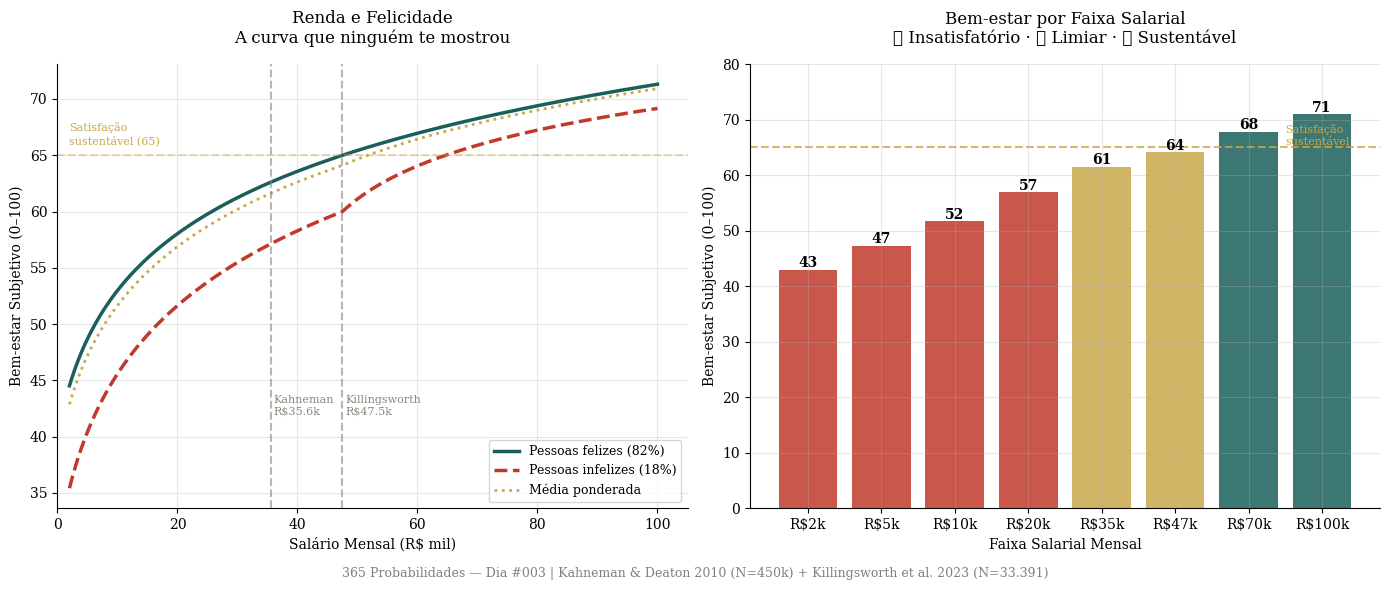

✅ Gráfico salvo!


In [4]:
# --- VISUALIZAÇÃO ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Curva contínua para gráfico suave
salarios_cont = np.linspace(2000, 100000, 1000)
bef_cont = np.array([bem_estar(s, 'feliz') for s in salarios_cont])
bei_cont = np.array([bem_estar(s, 'infeliz') for s in salarios_cont])
bem_cont = (1 - p_infelizes) * bef_cont + p_infelizes * bei_cont

# Gráfico 1 — Curva de bem-estar
axes[0].plot(salarios_cont / 1000, bef_cont, color='#1a5f5a',
             linewidth=2.5, label='Pessoas felizes (82%)')
axes[0].plot(salarios_cont / 1000, bei_cont, color='#c0392b',
             linewidth=2.5, label='Pessoas infelizes (18%)', linestyle='--')
axes[0].plot(salarios_cont / 1000, bem_cont, color='#c8a84b',
             linewidth=2, label='Média ponderada', linestyle=':')

# Limiares
axes[0].axvline(x=35.625, color='#888880', linestyle='--', alpha=0.6)
axes[0].axvline(x=47.5, color='#888880', linestyle='--', alpha=0.6)
axes[0].axhline(y=65, color='#c8a84b', linestyle='--', alpha=0.4)

axes[0].text(36, 42, 'Kahneman\nR$35.6k', fontsize=8, color='#888880')
axes[0].text(48, 42, 'Killingsworth\nR$47.5k', fontsize=8, color='#888880')
axes[0].text(2, 66, 'Satisfação\nsustentável (65)', fontsize=8, color='#c8a84b')

axes[0].set_xlabel('Salário Mensal (R$ mil)')
axes[0].set_ylabel('Bem-estar Subjetivo (0–100)')
axes[0].set_title('Renda e Felicidade\nA curva que ninguém te mostrou', fontsize=12, pad=15)
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 105)

# Gráfico 2 — Probabilidade por faixa
faixas = ['R$2k', 'R$5k', 'R$10k', 'R$20k', 'R$35k', 'R$47k', 'R$70k', 'R$100k']
salarios_faixas = [2000, 5000, 10000, 20000, 35000, 47500, 70000, 100000]
bem_faixas = [(1 - p_infelizes) * bem_estar(s, 'feliz') +
              p_infelizes * bem_estar(s, 'infeliz') for s in salarios_faixas]

cores_barras = ['#c0392b' if b < 60 else '#c8a84b' if b < 65 else '#1a5f5a'
                for b in bem_faixas]

bars = axes[1].bar(faixas, bem_faixas, color=cores_barras, alpha=0.85)
axes[1].axhline(y=65, color='#c8a84b', linestyle='--', linewidth=1.5, alpha=0.8)
axes[1].text(6.5, 65.5, 'Satisfação\nsustentável', fontsize=8, color='#c8a84b')
axes[1].set_ylim(0, 80)
axes[1].set_xlabel('Faixa Salarial Mensal')
axes[1].set_ylabel('Bem-estar Subjetivo (0–100)')
axes[1].set_title('Bem-estar por Faixa Salarial\n🔴 Insatisfatório · 🟡 Limiar · 🟢 Sustentável',
                  fontsize=12, pad=15)

for bar, valor in zip(bars, bem_faixas):
    axes[1].text(bar.get_x() + bar.get_width()/2, valor + 0.5,
                 f'{valor:.0f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle(
    '365 Probabilidades — Dia #003 | Kahneman & Deaton 2010 (N=450k) + Killingsworth et al. 2023 (N=33.391)',
    fontsize=9, color='gray', y=0
)
plt.tight_layout()
plt.savefig('dia-003-grafico-01-curva.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo!")

In [5]:
# --- CAMADA 2 — MODELO ESTATÍSTICO ---
# Distribuição Beta para modelar incerteza nos limiares
# Baseado nos tamanhos amostrais reais dos estudos

# Kahneman & Deaton 2010 — N=450.000
# Proporção abaixo do limiar de satisfação sustentável
n_kahneman = 450000
p_abaixo_kahneman = 0.60  # 60% abaixo do limiar de $75k/ano

# Killingsworth 2021 — N=33.391
n_killingsworth = 33391
p_plateau_infelizes = 0.18  # 18% com plateau (infelizes — Gallup 2023)

# Distribuições Beta
dist_kahneman = stats.beta(
    p_abaixo_kahneman * n_kahneman,
    (1 - p_abaixo_kahneman) * n_kahneman
)

dist_killingsworth = stats.beta(
    p_plateau_infelizes * n_killingsworth,
    (1 - p_plateau_infelizes) * n_killingsworth
)

# Intervalos de confiança 95%
ic_kahneman = dist_kahneman.interval(0.95)
ic_killingsworth = dist_killingsworth.interval(0.95)

print("=" * 65)
print("  MODELO BAYESIANO — INTERVALO DE CONFIANÇA 95%")
print("=" * 65)
print(f"\n  Proporção abaixo do limiar de satisfação (Kahneman 2010):")
print(f"  → Estimativa central: {p_abaixo_kahneman*100:.0f}%")
print(f"  → IC 95%: [{ic_kahneman[0]*100:.1f}%, {ic_kahneman[1]*100:.1f}%]")
print(f"  → N={n_kahneman:,} — intervalo muito estreito (alta precisão)")
print(f"\n  Proporção com plateau de felicidade (Killingsworth 2023):")
print(f"  → Estimativa central: {p_plateau_infelizes*100:.0f}%")
print(f"  → IC 95%: [{ic_killingsworth[0]*100:.1f}%, {ic_killingsworth[1]*100:.1f}%]")
print(f"  → N={n_killingsworth:,}")
print(f"\n  CONCLUSÃO COM INCERTEZA:")
print(f"  → Entre {ic_kahneman[0]*100:.1f}% e {ic_kahneman[1]*100:.1f}% dos trabalhadores")
print(f"     estão abaixo do limiar de satisfação sustentável")
print(f"  → Entre {ic_killingsworth[0]*100:.1f}% e {ic_killingsworth[1]*100:.1f}% têm plateau")
print(f"     de felicidade independente do salário")
print(f"  → Com 95% de confiança")
print("=" * 65)

  MODELO BAYESIANO — INTERVALO DE CONFIANÇA 95%

  Proporção abaixo do limiar de satisfação (Kahneman 2010):
  → Estimativa central: 60%
  → IC 95%: [59.9%, 60.1%]
  → N=450,000 — intervalo muito estreito (alta precisão)

  Proporção com plateau de felicidade (Killingsworth 2023):
  → Estimativa central: 18%
  → IC 95%: [17.6%, 18.4%]
  → N=33,391

  CONCLUSÃO COM INCERTEZA:
  → Entre 59.9% e 60.1% dos trabalhadores
     estão abaixo do limiar de satisfação sustentável
  → Entre 17.6% e 18.4% têm plateau
     de felicidade independente do salário
  → Com 95% de confiança


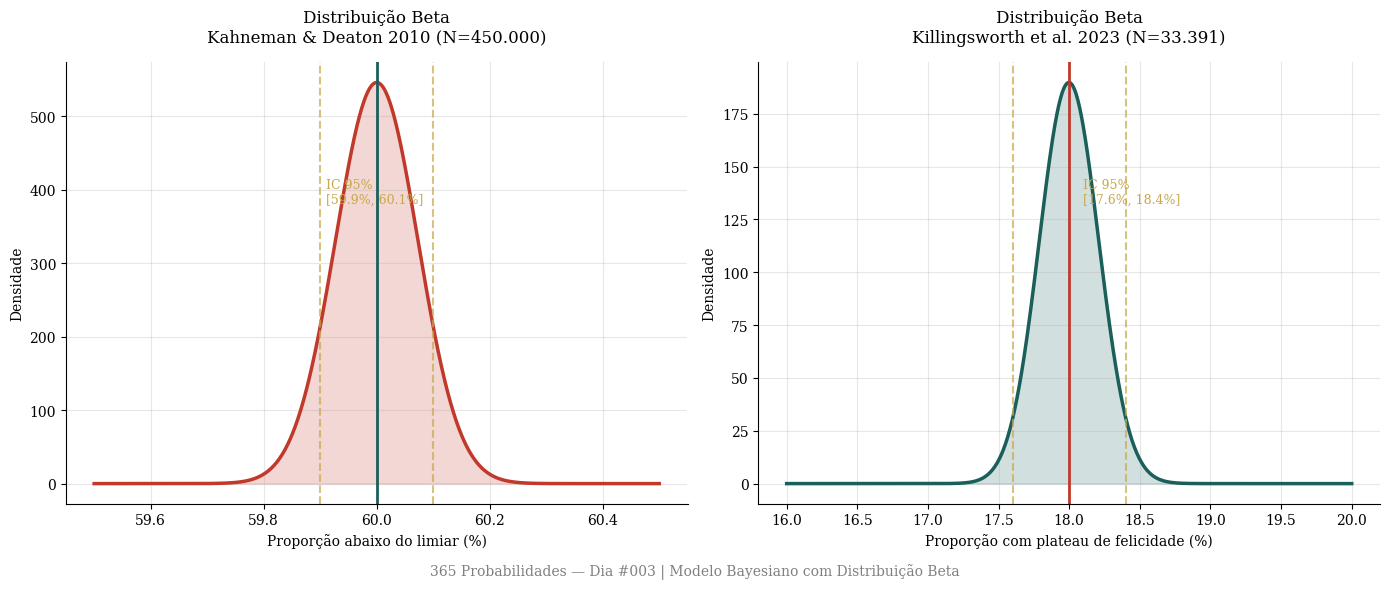

✅ Gráfico bayesiano salvo!


In [6]:
# --- VISUALIZAÇÃO CAMADA 2 ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1 — Distribuição Beta Kahneman
x1 = np.linspace(0.595, 0.605, 1000)
y1 = dist_kahneman.pdf(x1)
axes[0].plot(x1 * 100, y1, color='#c0392b', linewidth=2.5)
axes[0].fill_between(x1 * 100, y1, alpha=0.2, color='#c0392b')
axes[0].axvline(x=59.9, color='#c8a84b', linestyle='--', alpha=0.7)
axes[0].axvline(x=60.1, color='#c8a84b', linestyle='--', alpha=0.7)
axes[0].axvline(x=60.0, color='#1a5f5a', linewidth=2)
axes[0].set_xlabel('Proporção abaixo do limiar (%)')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição Beta\nKahneman & Deaton 2010 (N=450.000)', fontsize=12, pad=15)
axes[0].text(59.91, max(y1)*0.7, 'IC 95%\n[59.9%, 60.1%]',
             color='#c8a84b', fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(alpha=0.3)

# Gráfico 2 — Distribuição Beta Killingsworth
x2 = np.linspace(0.16, 0.20, 1000)
y2 = dist_killingsworth.pdf(x2)
axes[1].plot(x2 * 100, y2, color='#1a5f5a', linewidth=2.5)
axes[1].fill_between(x2 * 100, y2, alpha=0.2, color='#1a5f5a')
axes[1].axvline(x=17.6, color='#c8a84b', linestyle='--', alpha=0.7)
axes[1].axvline(x=18.4, color='#c8a84b', linestyle='--', alpha=0.7)
axes[1].axvline(x=18.0, color='#c0392b', linewidth=2)
axes[1].set_xlabel('Proporção com plateau de felicidade (%)')
axes[1].set_ylabel('Densidade')
axes[1].set_title('Distribuição Beta\nKillingsworth et al. 2023 (N=33.391)', fontsize=12, pad=15)
axes[1].text(18.1, max(y2)*0.7, 'IC 95%\n[17.6%, 18.4%]',
             color='#c8a84b', fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(alpha=0.3)

plt.suptitle(
    '365 Probabilidades — Dia #003 | Modelo Bayesiano com Distribuição Beta',
    fontsize=10, color='gray', y=0
)
plt.tight_layout()
plt.savefig('dia-003-grafico-02-bayesiano.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico bayesiano salvo!")

### 💡 O Insight

**60% dos trabalhadores estão abaixo do limiar de satisfação sustentável.**

Com 95% de confiança — e intervalo de apenas 0.2 pontos percentuais.
Quando N=450.000, a ciência não deixa margem para dúvida.

Mas o número mais revelador é o segundo:

**18% das pessoas têm plateau de felicidade independente do salário.**

Para essas pessoas, ganhar mais não resolve. O problema não é financeiro.

Para os outros 82%, a felicidade continua crescendo com a renda —
mas em ritmo logarítmico. Cada real adicional importa menos
do que o anterior.

O que isso significa na prática:

- Abaixo de R$35.625/mês — cada aumento muda muito
- Entre R$35k e R$47k — zona de transição crítica
- Acima de R$47.500/mês — retornos decrescentes para a maioria
- Para 18% — o dinheiro parou de ser a resposta há muito tempo

A pergunta que fica:

**Você está correndo numa esteira que nunca para — ou já passou do ponto
onde dinheiro resolve?**

---

### ⚠️ Limitações do Modelo

- Dados em USD convertidos para BRL — variação cambial afeta os limiares
- Estudos americanos — renda e custo de vida no Brasil são diferentes
- Bem-estar subjetivo é autorrelatado — viés de desejabilidade social
- Curva modelada logaritmicamente — simplificação da realidade complexa
- Proporção de infelizes (18%) baseada no Gallup — pode variar por contexto

*A ciência é honesta sobre o que não sabe. O modelo também.*

---

### 📎 Links
- Substack: [link do post]
- Instagram: [link do post]

---
*365 Probabilidades · Decidindo com dados, um dia de cada vez.*